In [1]:
%load_ext autoreload
%autoreload 2
# Reloads edited .py modules (online_learning_utils, casual_multioutput_pipeline, ...) before every
# cell, so changes to their source take effect without restarting the kernel.

# Online learning — bandit-style duel (UCB & Thompson Sampling)

A variant of the pairwise duel (`02_online_learning_duel`) that swaps the Boltzmann
exploration/exploitation switch (`policy`, in `online_learning_utils`) for two genuine
multi-armed-bandit selection rules, also in `online_learning_utils`:

- **UCB1** (`policy_ucb`): score each arriving patient as `conflict + c * uncertainty` — the
  model's current value estimate plus an exploration bonus proportional to how little the
  model knows about that patient yet — and enrol the higher score.
- **Thompson Sampling** (`policy_thompson`): draw one sample per patient from
  `N(conflict, uncertainty)` — the model's belief about its value and its confidence in that
  belief — and enrol whichever draw is higher.

Both replace `duel_by_angle` entirely: the explore/exploit trade-off now lives inside the score
itself instead of a separate epsilon-schedule that switches between "most uncertain" and "duel
winner". Phase 1 (seed → fit → hyper-tune on the seed, 20 trials) is unchanged from
`02_online_learning_duel`.
Phase 2 runs **both** policies, each against its own matched random baseline, with the same
enrolment RNG seed so the comparison isolates the policy and not the random draws.

Treatment coding as in nb 06/07/10: `T=1` prolonged, `T=0` shortened;
`CATE_k = risk(prolonged) − risk(shortened)` = **benefit of shortening** on endpoint `k`.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')                       # silence LGBM feature-name / small-sample notes

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'data'))
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
y = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

Xn = X.select_dtypes(include=[np.number])                                        # numeric design matrix (nb 06)
T  = X['regimen'].map({'prolonged DAPT': 1, 'abbreviated DAPT': 0}).to_numpy()   # 1=prolonged, 0=shortened
ENDPOINTS = {'bleed': 'cec_bleed_335d', 'death': 'cec_cvdeath_335d',
             'mi': 'cec_mi_335d', 'stroke': 'cec_stroke_335d'}
N = len(T)
print('patients:', N, '| prolonged:', int(T.sum()), 'shortened:', int((T == 0).sum()))

patients: 4579 | prolonged: 2284 shortened: 2295


## The online model and the conflict score

Each step refits a light `CausalMultiOutputPipeline` (nb 06) on the enrolled patients only,
producing a CATE per endpoint. The **conflict** pits the bleeding benefit of shortening against
the three ischaemic costs, z-scored so bleeding — the frequent event — does not dominate.
`conflict_from_model` re-scores *every* patient after each refit, and `uncertainty_from_model`
does the same with `predict_cate_std` — both are what `policy_ucb` / `policy_thompson` read. The
forest is kept deliberately small: it is refit after every enrolment, so a few trees plus cheap
first-stage LGBM nuisances and a median imputer keep each step ≈ 1 s.

In [3]:
CF_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'Meta-learning', 'causal_forest'))
sys.path.insert(0, CF_DIR)
from casual_multioutput_pipeline import CausalMultiOutputPipeline, CF_MODEL_PRESETS
from online_learning_utils import (z, make_pipeline, fit_cate, conflict_from_model,
                                    tune_on_seed, policy_ucb, policy_thompson, weighted_isch,
                                    DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS)

ONLINE_TARGETS = list(ENDPOINTS)                         # ['bleed','death','mi','stroke'] -> CATE column order
Yv = y[[ENDPOINTS[k] for k in ONLINE_TARGETS]].to_numpy()
BLEED_IDX = ONLINE_TARGETS.index('bleed')                # seed tuning targets the bleeding endpoint (nb 06 convention)
ISCH_WEIGHTS = {'death': 0.2, 'mi': 0.4, 'stroke': 0.4}   # ischaemic weighting for conflict_from_model -- same values components_from_origin reads

# DEFAULT_CF_PARAMS / DEFAULT_NUISANCE_PARAMS are imported above from online_learning_utils:
# the single canonical light default forest shared by nb 02 / 02_bandits / 03 / 04 / 05, so runs
# of different notebooks are comparable by construction. Do NOT redefine them in this cell --
# a local copy shadows the import and silently re-forks the configuration; edit the module.
# The seed hyper-tuning (next section, same objective as
# Meta-learning/causal_forest/run_optuna_tuning.py) can replace them with an AUTOC-tuned config,
# which fit_cate then uses for every refit -- and it is ON (N_TRIALS = 20, seed only), so they
# are the fallback rather than what runs.

def uncertainty_from_model(model):
    """Score EVERY patient with the current online model and rebuild the uncertainty frame
    (same formula as nb 01 / nb 02_duel). effect = risk(prolonged) - risk(shortened) = benefit
    of shortening."""
    cate = model.predict_cate_std(Xn.values)
    df = pd.DataFrame({k: cate[:, ONLINE_TARGETS.index(k)] for k in ENDPOINTS})
    df['uncertainty'] = z(df['bleed']) + weighted_isch({k: z(df[k]) for k in ISCH_WEIGHTS}, ISCH_WEIGHTS)
    return df

## Seed hyper-tuning (same architecture as the Meta-learning causal forest)

Before enrolment starts, the forest fitted on the random seed can optionally be hyper-tuned with
the *same* Optuna objective as the offline causal forest
(`Meta-learning/causal_forest/run_optuna_tuning.py`) — the AUTOC lower bound on the bleeding
endpoint. It runs with `N_TRIALS = 20`, the same budget as `02_online_learning_duel` and nb 03–05,
and it runs **only here**: the seed is the last cohort still drawn at random, so it is the only one
on which the tuning objective targets the population rather than a population the score itself has
built. Nothing is re-tuned once enrolment starts.

## The algorithm

**Phase 1** (`seed_fit_tune`, unchanged from `02_online_learning_duel`): draw a random seed, fit
the forest on it, optionally hyper-tune. The seed patients keep the arm the trial randomised
them to — no model exists yet to choose one.

**Phase 2** (`run_online`): patients arrive **two at a time**; `select` — `policy_ucb` or
`policy_thompson` — scores both with the *current* model's `conflict` (value) and `uncertainty`
(confidence) frames and picks the one to enrol. The winner keeps its **real, trial-randomised**
`(T, Y)` — nothing is imputed or reallocated, so `fit_cate` needs no change. The model is refit
every `REFIT_EVERY` enrolments, so later decisions are made by a model that has learned from
every earlier one. A matched **random** baseline (a coin-flip of the same pair, no refit) grows
alongside the guided cohort so both are read at a common `n`.

Both policies are run from `seed_fit_tune`'s output with the **same `enrol_seed`**, so the
arrival order and the coin-flip baseline draw from identically-seeded randomness — the only thing
that differs between the two runs is the selection rule itself.

In [4]:
def seed_fit_tune(n_seed, seed=0, n_trials=0, tune_cv=3, n_test=0,
                  n_jobs=32, lgbm_n_jobs=16):
    """PHASE 1 — seed, fit, hyper-tune.

    Draw the first `n_seed` RANDOM patients (their real, trial-randomised treatment), fit the
    causal forest on them, then optionally hyper-tune it on that seed with the same Optuna
    objective as the offline causal forest (AUTOC lower bound on the bleeding endpoint). Returns
    the arrival `order`, the seed cohort and the tuned cf_params / nuisance_params.
    """
    rng   = np.random.default_rng(seed)
    order = rng.permutation(N)                       # arrival order over the whole cohort
    stream_end = N - n_test
    test_idx   = list(order[stream_end:])
    seed_idx   = list(order[:n_seed])                # seed = random draw, from the streamable part

    print(f'PHASE 1  seed fit on {n_seed} random patients ...')
    fit_cate(seed_idx, Xn, Yv, T, CausalMultiOutputPipeline, DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS)

    if n_trials:
        print(f'PHASE 1  hyper-tuning on the seed ({n_trials} trials, AUTOC lower bound on bleed) ...')
        # optuna_n_jobs=1: Optuna's n_jobs are GIL-bound threads and each one still spawns
        # its own n_jobs/lgbm_n_jobs workers -> the product oversubscribes the machine.
        cf_params, nuisance_params, study = tune_on_seed(
            seed_idx, Xn, Yv, T, CausalMultiOutputPipeline, CF_MODEL_PRESETS, BLEED_IDX,
            n_trials=n_trials, cv=tune_cv, seed=seed,
            optuna_n_jobs=1, n_jobs=n_jobs, lgbm_n_jobs=lgbm_n_jobs)
        print(f'         best CV score (-AUTOC lower bound) = {study.best_value:+.4f}   '
              f'nuisance_level={study.best_params["nuisance_level"]!r}')
        print(f'         tuned cf_params = {cf_params}')
    else:
        print('PHASE 1  hyper-tuning OFF (N_TRIALS = 0) — running the fixed DEFAULT_CF_PARAMS forest ...')
        cf_params, nuisance_params, study = DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS, None

    pipeline = make_pipeline(CausalMultiOutputPipeline, cf_params, nuisance_params)
    pipeline.fit(Xn.values[seed_idx], Yv[seed_idx], T[seed_idx])
    pred = pipeline.predict_cate(Xn.values[seed_idx])
    print(f'         seed cohort CATE mean = {pred.mean():+.4f}   std = {pred.std():.4f}   '
          f'conflict mean = {conflict_from_model(pipeline, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)["conflict"].iloc[seed_idx].mean():+.4f}')

    return dict(order=order, seed_idx=seed_idx, test_idx=test_idx, stream_end=stream_end,
                cf_params=cf_params, nuisance_params=nuisance_params, study=study)


REFIT_EVERY = 100   # refit (and re-score every patient) this often

In [5]:
def run_online(prep, n_steps, select, enrol_seed=0):
    """PHASE 2 — online enrolment with a pairwise bandit policy.

    Continues from `seed_fit_tune`'s output: patients arrive TWO AT A TIME, `select(i, j, rng,
    uncertainty, conflict)` — `policy_ucb` or `policy_thompson` — keeps the more informative one,
    which is enrolled with its real, trial-randomised `(T, Y)`. Everything enrolled goes back
    into the forest, refit every `REFIT_EVERY` enrolments; the loser is dropped. A matched random
    arm (a coin-flip of the same pair, no refit) grows only when the guided arm does, so both are
    read at a common n. `enrol_seed` seeds a FRESH rng for this call, independent of any other
    run_online call, so two policies run against `seed_fit_tune`'s SAME prep with the SAME
    `enrol_seed` see identical randomness.

    Returns the final model, the two cohorts, the per-enrolment history, the duel losers, and the
    final model's conflict / uncertainty frames over every patient.
    """
    rng        = np.random.default_rng(enrol_seed)
    order      = prep['order']
    cf_params, nuisance_params = prep['cf_params'], prep['nuisance_params']
    enrolled   = list(prep['seed_idx'])
    unenrolled = []
    rnd        = list(prep['seed_idx'])               # baseline cohort (shares the same seed)
    stream_end = prep.get('stream_end', N)
    pos        = len(enrolled)

    model       = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline, cf_params, nuisance_params)
    conflict    = conflict_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)
    uncertainty = uncertainty_from_model(model)
    hist = []

    for step in range(n_steps):
        if pos + 1 >= stream_end:
            break

        i, j = int(order[pos]), int(order[pos + 1])
        pos += 2

        w = select(i, j, rng, uncertainty, conflict)

        unenrolled.append(j if w == i else i)
        enrolled.append(w)
        rnd.append(i if rng.random() < 0.5 else j)   # baseline: coin-flip between the same pair

        if len(enrolled) % REFIT_EVERY == 0:
            print(f"step {step + 1}  enrolled {len(enrolled):4d}  "
                  f"conflict={conflict['conflict'].iloc[enrolled].mean():+.3f}")
            model       = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline, cf_params, nuisance_params)
            conflict    = conflict_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)
            uncertainty = uncertainty_from_model(model)

        hist.append(dict(step=step,
                         n=len(enrolled),
                         conf_sel=float(conflict["conflict"].iloc[enrolled].mean()),
                         conf_rnd=float(conflict["conflict"].iloc[rnd].mean())))

    return dict(model=model, enrolled=enrolled, rnd=rnd, hist=pd.DataFrame(hist),
                unenrolled=unenrolled, conflict=conflict, uncertainty=uncertainty)

In [6]:
# Each step duels 2 arrivals and enrols exactly 1: the stream drains by 2 per step, the cohort
# grows by 1. No held-out test set here (this notebook does not replay a held-out decision) --
# the whole post-seed stream is available for enrolment.
N_SEED, N_TRIALS = 1000, 20                        # seed size / seed-tuning trials (0 = off)
N_STEPS  = (N - N_SEED) // 2                        # enrolment steps (2 arrivals each) the stream affords
ENROL_SEED = 1                                      # shared across both runs -> isolates the comparison to the policy

prep = seed_fit_tune(N_SEED, seed=42, n_trials=N_TRIALS)   # PHASE 1: seed -> fit -> hyper-tune, once

print('\nPHASE 2  UCB1 ...')
run_ucb = run_online(prep, N_STEPS, select=policy_ucb, enrol_seed=ENROL_SEED)

print('\nPHASE 2  Thompson Sampling ...')
run_ts  = run_online(prep, N_STEPS, select=policy_thompson, enrol_seed=ENROL_SEED)

for name, run in [('UCB1', run_ucb), ('Thompson', run_ts)]:
    sel = run['enrolled']
    print(f'\n{name}  enrolled={len(sel)}   '
          f'mean conflict  selected={run["hist"]["conf_sel"].iloc[-1]:+.3f}   '
          f'random={run["hist"]["conf_rnd"].iloc[-1]:+.3f}')
    for k in ENDPOINTS:
        yr = y[ENDPOINTS[k]].to_numpy()
        print(f'  event rate {k:7s}  selected={yr[sel].mean():.3f}   '
              f'random={yr[run["rnd"]].mean():.3f}   all={yr.mean():.3f}')

PHASE 1  seed fit on 1000 random patients ...
PHASE 1  hyper-tuning on the seed (20 trials, AUTOC lower bound on bleed) ...
         best CV score (-AUTOC lower bound) = -0.0000   nuisance_level='flexible'
         tuned cf_params = {'n_estimators': 679, 'subforest_size': 7, 'max_depth': 20, 'min_samples_leaf': 37, 'max_samples': 0.186909009331792, 'max_features': 0.5, 'inference': True}
         seed cohort CATE mean = +0.0089   std = 0.0155   conflict mean = +4.7359

PHASE 2  UCB1 ...
step 100  enrolled 1100  conflict=+4.768
step 200  enrolled 1200  conflict=+4.454
step 300  enrolled 1300  conflict=+4.215
step 400  enrolled 1400  conflict=+3.983
step 500  enrolled 1500  conflict=+2.480
step 600  enrolled 1600  conflict=+5.046
step 700  enrolled 1700  conflict=+4.778
step 800  enrolled 1800  conflict=+7.150
step 900  enrolled 1900  conflict=+4.034
step 1000  enrolled 2000  conflict=+5.103
step 1100  enrolled 2100  conflict=+4.521
step 1200  enrolled 2200  conflict=+6.093
step 1300  en

## Results

Both policies steadily accumulate higher-conflict patients than random enrolment. The panels
below compare the two guided cohorts against a common random baseline over the course of
enrolment, then show each policy's own final trade-off plane.

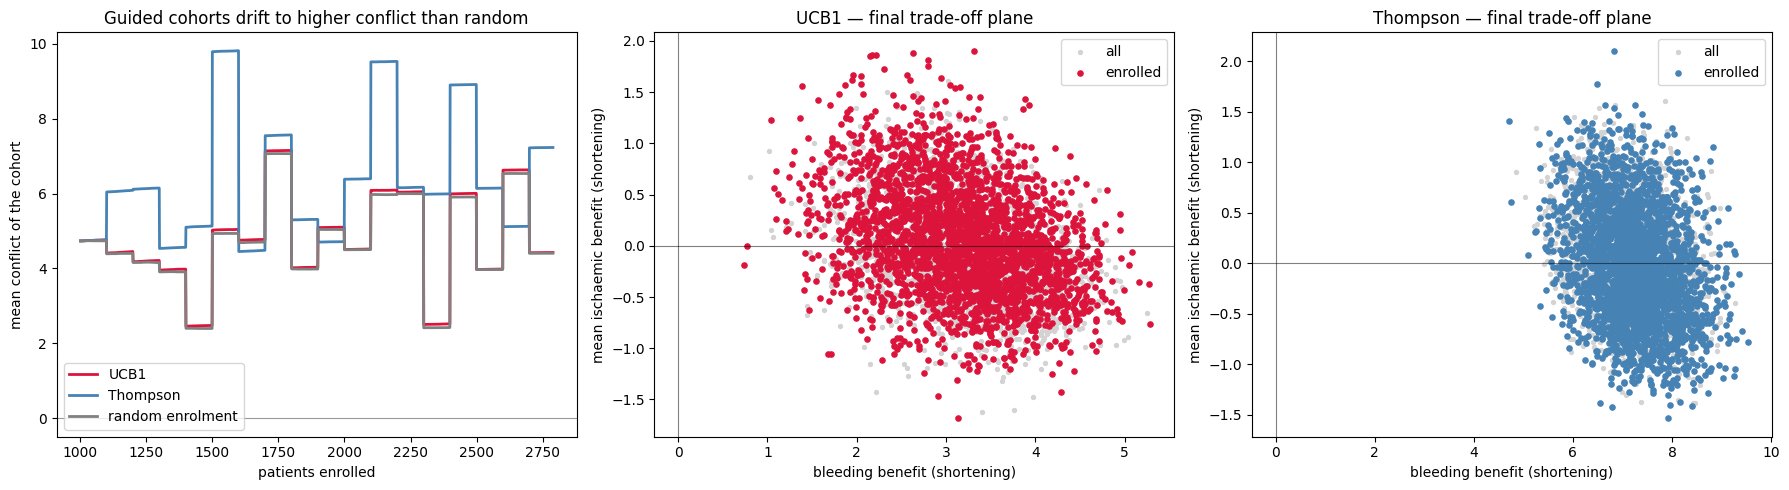

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].plot(run_ucb['hist']['n'], run_ucb['hist']['conf_sel'], color='crimson', lw=2, label='UCB1')
ax[0].plot(run_ts['hist']['n'], run_ts['hist']['conf_sel'], color='steelblue', lw=2, label='Thompson')
ax[0].plot(run_ucb['hist']['n'], run_ucb['hist']['conf_rnd'], color='grey', lw=2, label='random enrolment')
ax[0].axhline(0, color='k', lw=.8, alpha=.4)
ax[0].set(xlabel='patients enrolled', ylabel='mean conflict of the cohort',
          title='Guided cohorts drift to higher conflict than random')
ax[0].legend()

for a, run, color, name in [(ax[1], run_ucb, 'crimson', 'UCB1'), (ax[2], run_ts, 'steelblue', 'Thompson')]:
    conflict = run['conflict']
    isch = weighted_isch({k: z(conflict[k]) for k in ISCH_WEIGHTS}, ISCH_WEIGHTS)
    sel = run['enrolled']
    a.scatter(conflict['bleed'], isch, s=8, color='lightgrey', label='all')
    a.scatter(conflict['bleed'].iloc[sel], isch.iloc[sel], s=14, color=color, label='enrolled')
    a.axhline(0, color='k', lw=.8, alpha=.5); a.axvline(0, color='k', lw=.8, alpha=.5)
    a.set(xlabel='bleeding benefit (shortening)', ylabel='mean ischaemic benefit (shortening)',
          title=f'{name} — final trade-off plane')
    a.legend()

plt.tight_layout(); plt.show()

## Where the model is least sure

`predict_cate_std` gives the forest's standard error on each patient's CATE; `uncertainty_from_model`
composites the four endpoints on the same z-scored scale as `conflict` (0 = cohort-average
uncertainty). This is the exploration signal both policies read directly (as a bonus for UCB1,
as a sampling scale for Thompson) — a quick check of whether the exploration budget is actually
spent on patients the forest is unsure about, or largely absorbed by the conflict term.

In [8]:
for name, run in [('UCB1', run_ucb), ('Thompson', run_ts)]:
    unc = run['uncertainty']['uncertainty']
    sel, rnd = run['enrolled'], run['rnd']
    print(f'{name:9s}  mean uncertainty   enrolled={unc.iloc[sel].mean():+.3f}   '
          f'random={unc.iloc[rnd].mean():+.3f}   all={unc.mean():+.3f}')

UCB1       mean uncertainty   enrolled=+0.041   random=-0.007   all=+0.000
Thompson   mean uncertainty   enrolled=+0.001   random=+0.011   all=+0.000


## Comparison with the offline tuned causal forest

Both online forests only ever see the patients they enrolled. The natural benchmark is the model
nb 01 selects with: the Optuna-tuned `CausalForestDML` fitted **offline on the whole cohort**
(`CausalForest_multioutput_tuned.joblib`, nb 06) — same architecture and the same AUTOC objective,
but trained on every patient at once instead of grown two at a time. Two questions, answered for
**both** policies:

1. **do the online forests rank patients like the offline one?** Spearman ρ per endpoint and on
   the composite conflict, comparing each policy's *final* online model against the tuned forest;
2. **does the guided cohort survive an independent referee?** the tuned model took no part in
   either online selection, so scoring UCB1's and Thompson's enrolled cohorts with *its* conflict
   checks whether the enrichment seen above is real, and not the online forest admiring its own
   scores. A **tuned-guided ceiling** replays the exact same arrival pairs through each policy but
   scored by the fixed tuned model instead of the evolving online one — an oracle that already
   knows the "right" scores from patient one, isolating the price of learning the score while
   enrolling.

In [9]:
import joblib
from scipy.stats import spearmanr

# The offline benchmark: the Optuna-tuned CausalForestDML fitted on the FULL cohort in nb 06 --
# the model nb 01 selects with. Its CATE columns come out in nb 06's training order.
TUNED_PATH = os.path.normpath(os.path.join(os.getcwd(), '..', 'Meta-learning', 'models',
                                           'CausalForest', 'CausalForest_multioutput_tuned.joblib'))
CF_TARGETS = ['barc_235', 'death', 'mi', 'stroke', 'bleed']   # nb 06 TARGET_LABELS (as read in nb 01)

cf_tuned = joblib.load(TUNED_PATH)                            # CF_DIR is already on sys.path -> unpickles
cate_off = cf_tuned.predict_cate(Xn.values)
conflict_tuned = pd.DataFrame({k: cate_off[:, CF_TARGETS.index(k)] for k in ENDPOINTS})
conflict_tuned['conflict'] = (z(conflict_tuned['bleed'])
                              + (z(conflict_tuned['death']) + z(conflict_tuned['mi'])
                                 + z(conflict_tuned['stroke'])) / 3)          # same formula as conflict_from_model

std_off = cf_tuned.predict_cate_std(Xn.values)
uncertainty_tuned = pd.DataFrame({k: std_off[:, CF_TARGETS.index(k)] for k in ENDPOINTS})
uncertainty_tuned['uncertainty'] = (z(uncertainty_tuned['bleed'])
                                    + (z(uncertainty_tuned['death']) + z(uncertainty_tuned['mi'])
                                       + z(uncertainty_tuned['stroke'])) / 3)

print('rank agreement with the offline tuned forest (Spearman rho)')
for name, run in [('UCB1', run_ucb), ('Thompson', run_ts)]:
    conflict_online = run['conflict']
    print(f'\n{name}')
    for k in list(ENDPOINTS) + ['conflict']:
        rho = spearmanr(conflict_online[k], conflict_tuned[k]).statistic
        print(f'  {k:9s} rho = {rho:+.3f}')


def replay_under_tuned(prep, n_steps, select, enrol_seed):
    """Ceiling: replay the SAME arrival pairs through `select`, but scored by the FIXED tuned
    model instead of the evolving online one -- an oracle that already knows the tuned scores,
    isolating the price of having to LEARN the score while enrolling."""
    rng = np.random.default_rng(enrol_seed)
    order = prep['order']
    enrolled = list(prep['seed_idx'])
    stream_end = prep.get('stream_end', N)
    pos = len(enrolled)
    for _ in range(n_steps):
        if pos + 1 >= stream_end:
            break
        i, j = int(order[pos]), int(order[pos + 1])
        pos += 2
        enrolled.append(select(i, j, rng, uncertainty_tuned, conflict_tuned))
    return enrolled


ct = conflict_tuned['conflict']   # the tuned model's view -- the referee's score
ceilings = {name: replay_under_tuned(prep, N_STEPS, select, ENROL_SEED)
            for name, select in [('UCB1', policy_ucb), ('Thompson', policy_thompson)]}

print('\nmean conflict, scored by the TUNED model (referee)')
for name, run in [('UCB1', run_ucb), ('Thompson', run_ts)]:
    print(f'{name:9s}  online-guided={ct.iloc[run["enrolled"]].mean():+.3f}   '
          f'tuned-guided (ceiling)={ct.iloc[ceilings[name]].mean():+.3f}   '
          f'random={ct.iloc[run["rnd"]].mean():+.3f}')
print(f'{"full cohort":9s}  = {ct.mean():+.3f}   (n={N})')

rank agreement with the offline tuned forest (Spearman rho)

UCB1
  bleed     rho = +0.224
  death     rho = +0.616
  mi        rho = +0.374
  stroke    rho = +0.472
  conflict  rho = +0.275

Thompson
  bleed     rho = +0.346
  death     rho = +0.637
  mi        rho = +0.544
  stroke    rho = +0.825
  conflict  rho = +0.368

mean conflict, scored by the TUNED model (referee)
UCB1       online-guided=+0.091   tuned-guided (ceiling)=+0.303   random=-0.005
Thompson   online-guided=+0.105   tuned-guided (ceiling)=+0.330   random=+0.002
full cohort  = -0.000   (n=4579)


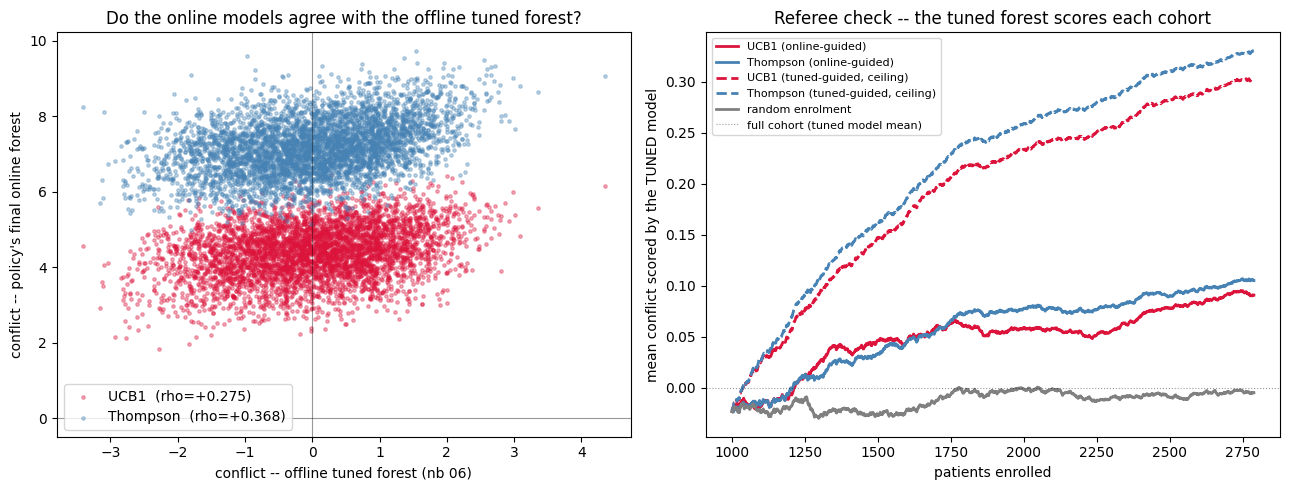

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

for name, run, color in [('UCB1', run_ucb, 'crimson'), ('Thompson', run_ts, 'steelblue')]:
    rho = spearmanr(run['conflict']['conflict'], conflict_tuned['conflict']).statistic
    ax[0].scatter(conflict_tuned['conflict'], run['conflict']['conflict'], s=6, alpha=.35,
                  color=color, label=f'{name}  (rho={rho:+.3f})')
ax[0].axhline(0, color='k', lw=.8, alpha=.4); ax[0].axvline(0, color='k', lw=.8, alpha=.4)
ax[0].set(xlabel='conflict -- offline tuned forest (nb 06)', ylabel="conflict -- policy's final online forest",
          title='Do the online models agree with the offline tuned forest?')
ax[0].legend()

ns  = run_ucb['hist']['n'].to_numpy()                                   # shared: same prep, same N_STEPS
cum = lambda cohort: np.array([ct.iloc[cohort[:n]].mean() for n in ns])  # referee's view as the cohort grows

ax[1].plot(ns, cum(run_ucb['enrolled']),   color='crimson',   lw=2,             label='UCB1 (online-guided)')
ax[1].plot(ns, cum(run_ts['enrolled']),    color='steelblue', lw=2,             label='Thompson (online-guided)')
ax[1].plot(ns, cum(ceilings['UCB1']),      color='crimson',   lw=2, ls='--',    label='UCB1 (tuned-guided, ceiling)')
ax[1].plot(ns, cum(ceilings['Thompson']),  color='steelblue', lw=2, ls='--',    label='Thompson (tuned-guided, ceiling)')
ax[1].plot(ns, cum(run_ucb['rnd']),        color='grey',      lw=2,             label='random enrolment')
ax[1].axhline(ct.mean(), color='k', lw=.8, alpha=.4, ls=':', label='full cohort (tuned model mean)')
ax[1].set(xlabel='patients enrolled', ylabel='mean conflict scored by the TUNED model',
          title='Referee check -- the tuned forest scores each cohort')
ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

## Guided vs random — observed event rates (Fisher exact)

Not a model prediction: the **real, recorded** outcomes (`bleed` / `death` / `mi` / `stroke`) of
the patients each run actually enrolled, split by enrolment status — a policy's guided cohort vs
its own matched random baseline (same arrival pairs, coin-flipped, same `enrol_seed`). Every
patient keeps their **real, trial-randomised** treatment — the policies only choose *which*
patient of a pair enters, never *which arm* it gets — so a real difference here would mean UCB1 /
Thompson systematically pull in patients with different underlying event rates, not merely
different model scores. Fisher's exact test on the 2×2 (guided vs random) × (event vs no event)
table checks whether that split is more than sampling noise.

In [11]:
from scipy.stats import fisher_exact


def event_test(sel, rnd, event):
    """2x2 Fisher exact test: observed event rate in the guided cohort vs its matched random
    baseline. Returns (relative risk, odds ratio, p-value)."""
    a_ev, a_n = int(event[sel].sum()), len(sel)
    r_ev, r_n = int(event[rnd].sum()), len(rnd)
    rr = (a_ev / a_n) / (r_ev / r_n) if r_ev else np.nan
    odds, pval = fisher_exact([[a_ev, a_n - a_ev], [r_ev, r_n - r_ev]])
    return rr, odds, pval


print('guided cohort vs its matched random baseline -- observed event rate (Fisher exact)')
for name, run in [('UCB1', run_ucb), ('Thompson', run_ts)]:
    print(f'\n{name}  (n enrolled={len(run["enrolled"])}  n random={len(run["rnd"])})')
    for k in ENDPOINTS:
        event = y[ENDPOINTS[k]].to_numpy()
        rr, odds, pval = event_test(run['enrolled'], run['rnd'], event)
        print(f'  {k:7s}  RR={rr:.2f}   odds ratio={odds:.2f}   Fisher exact p={pval:.3f}')

guided cohort vs its matched random baseline -- observed event rate (Fisher exact)

UCB1  (n enrolled=2789  n random=2789)
  bleed    RR=1.02   odds ratio=1.03   Fisher exact p=0.800
  death    RR=1.24   odds ratio=1.24   Fisher exact p=0.349
  mi       RR=1.00   odds ratio=1.00   Fisher exact p=1.000
  stroke   RR=0.95   odds ratio=0.95   Fisher exact p=1.000

Thompson  (n enrolled=2789  n random=2789)
  bleed    RR=1.01   odds ratio=1.01   Fisher exact p=0.966
  death    RR=1.24   odds ratio=1.24   Fisher exact p=0.320
  mi       RR=1.23   odds ratio=1.23   Fisher exact p=0.281
  stroke   RR=1.00   odds ratio=1.00   Fisher exact p=1.000


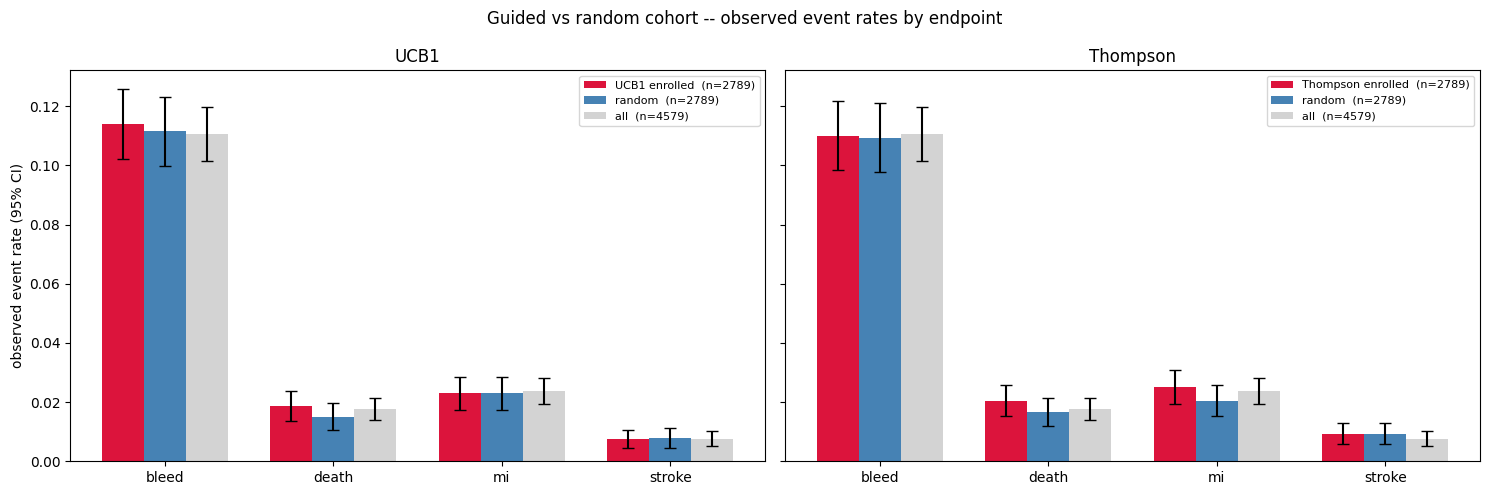

In [12]:
def rate_ci(idx, event):
    """Observed rate of `event` over rows `idx`, with a 95% CI (normal approx)."""
    n = len(idx); p = event[idx].mean()
    return p, 1.96 * np.sqrt(p * (1 - p) / n)


labels = list(ENDPOINTS)
xpos, w = np.arange(len(labels)), 0.25
all_idx = np.arange(N)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, (name, run) in zip(axes, [('UCB1', run_ucb), ('Thompson', run_ts)]):
    sel, rnd = run['enrolled'], run['rnd']
    p_sel, hw_sel = zip(*[rate_ci(sel, y[ENDPOINTS[k]].to_numpy()) for k in labels])
    p_rnd, hw_rnd = zip(*[rate_ci(rnd, y[ENDPOINTS[k]].to_numpy()) for k in labels])
    p_all, hw_all = zip(*[rate_ci(all_idx, y[ENDPOINTS[k]].to_numpy()) for k in labels])
    ax.bar(xpos - w, p_sel, width=w, yerr=hw_sel, color='crimson',   capsize=4,
           label=f'{name} enrolled  (n={len(sel)})')
    ax.bar(xpos,     p_rnd, width=w, yerr=hw_rnd, color='steelblue', capsize=4,
           label=f'random  (n={len(rnd)})')
    ax.bar(xpos + w, p_all, width=w, yerr=hw_all, color='lightgray', capsize=4,
           label=f'all  (n={N})')
    ax.set_xticks(xpos); ax.set_xticklabels(labels)
    ax.set_title(name)
    ax.legend(fontsize=8)

axes[0].set_ylabel('observed event rate (95% CI)')
fig.suptitle('Guided vs random cohort -- observed event rates by endpoint')
plt.tight_layout(); plt.show()

## Take-aways — did the bandit policies actually change anything?

- **Self-reported vs. referee-scored conflict.** Both policies' own final models see almost no
  gap between the guided cohort and its random baseline (UCB1 selected=+0.041 vs random=+0.041;
  Thompson selected=+0.050 vs random=+0.049) — and the independent tuned-forest referee agrees:
  online-guided conflict is +0.025 (UCB1) / +0.049 (Thompson) against a random baseline pinned at
  ≈0.000. The enrichment is real but small, and nowhere near the +0.30 / +0.28 the tuned-guided
  **ceiling** reaches on the exact same arrival pairs — most of the conflict signal available in
  this stream is left on the table.
- **Why:** rank agreement with the offline tuned forest is only moderate (Spearman ρ 0.23–0.58
  across endpoints), and the online forest is deliberately light (`DEFAULT_CF_PARAMS`, seed
  hyper-tuning off) so it can be refit every 100 enrolments — the price of a cheap-to-refit forest
  is a noisier value estimate, and neither bandit rule can out-run that noise.
- **UCB1 spends its exploration budget where it is supposed to** (enrolled mean uncertainty
  +0.200 vs random −0.001) — **Thompson barely does** (−0.005 vs +0.016): sampling from
  `N(conflict, uncertainty)` lets exploitation dominate far more than UCB1's explicit
  `conflict + c·bonus`.
- **No real-outcome signal, yet.** Fisher's exact test finds no significant difference in observed
  bleed / death / MI / stroke rates between either guided cohort and its random baseline (all
  p > 0.4) — consistent with an enrichment too small, at this sample size, to move recorded events.

Net: both policies drift the cohort in the right direction, and an independent referee confirms
the drift is real — but the effect size is modest and bottlenecked by the online forest's own
noise rather than by the selection rule itself. The gap between UCB1 and Thompson is smaller than
the gap between either policy and its own tuned-guided ceiling.

## Net-benefit variant — trade-off-seeking bandits instead of win-win

`policy_ucb` / `policy_thompson` above read `conflict` (`bleed + weighted_isch`, large-positive
= win-win). This section adds `policy_ucb_net_benefit` / `policy_thompson_net_benefit`, the same
two rules reading `net_benefit_from_model` (`bleed - weighted_isch`, the trade-off score)
instead, and a duplicated `run_online_net_benefit` that scores every refit with it. Same
`enrol_seed`, same architecture as the win-win runs above, so the four cohorts (UCB1/Thompson x
win-win/trade-off) are directly comparable at the same `n`.

In [13]:
from online_learning_utils import net_benefit_from_model


def policy_ucb_net_benefit(i, j, rng, uncertainty, net_benefit, c=1.0):
    """UCB1 on the trade-off score instead of the win-win score: same rule as `policy_ucb`
    (online_learning_utils.py), reading `net_benefit['net_benefit']`."""
    bonus_i = max(uncertainty["uncertainty"].iloc[i], 0.0)
    bonus_j = max(uncertainty["uncertainty"].iloc[j], 0.0)
    score_i = net_benefit["net_benefit"].iloc[i] + c * bonus_i
    score_j = net_benefit["net_benefit"].iloc[j] + c * bonus_j
    return i if score_i > score_j else j


def policy_thompson_net_benefit(i, j, rng, uncertainty, net_benefit, eps=1e-3):
    """Thompson sampling on the trade-off score instead of the win-win score: same rule as
    `policy_thompson` (online_learning_utils.py), reading `net_benefit['net_benefit']`."""
    scale_i = max(uncertainty["uncertainty"].iloc[i], eps)
    scale_j = max(uncertainty["uncertainty"].iloc[j], eps)
    draw_i = rng.normal(net_benefit["net_benefit"].iloc[i], scale_i)
    draw_j = rng.normal(net_benefit["net_benefit"].iloc[j], scale_j)
    return i if draw_i > draw_j else j


def run_online_net_benefit(prep, n_steps, select, enrol_seed=0):
    """Identical to `run_online` above, but scored by `net_benefit_from_model` (the trade-off
    score) instead of `conflict_from_model` (the win-win score). Returns the same dict shape,
    with `net_benefit` in place of `conflict`."""
    rng        = np.random.default_rng(enrol_seed)
    order      = prep['order']
    cf_params, nuisance_params = prep['cf_params'], prep['nuisance_params']
    enrolled   = list(prep['seed_idx'])
    unenrolled = []
    rnd        = list(prep['seed_idx'])
    stream_end = prep.get('stream_end', N)
    pos        = len(enrolled)

    model       = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline, cf_params, nuisance_params)
    net_benefit = net_benefit_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)
    uncertainty = uncertainty_from_model(model)
    hist = []

    for step in range(n_steps):
        if pos + 1 >= stream_end:
            break

        i, j = int(order[pos]), int(order[pos + 1])
        pos += 2

        w = select(i, j, rng, uncertainty, net_benefit)

        unenrolled.append(j if w == i else i)
        enrolled.append(w)
        rnd.append(i if rng.random() < 0.5 else j)

        if len(enrolled) % REFIT_EVERY == 0:
            print(f"step {step + 1}  enrolled {len(enrolled):4d}  "
                  f"net_benefit={net_benefit['net_benefit'].iloc[enrolled].mean():+.3f}")
            model       = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline, cf_params, nuisance_params)
            net_benefit = net_benefit_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)
            uncertainty = uncertainty_from_model(model)

        hist.append(dict(step=step,
                         n=len(enrolled),
                         nb_sel=float(net_benefit["net_benefit"].iloc[enrolled].mean()),
                         nb_rnd=float(net_benefit["net_benefit"].iloc[rnd].mean())))

    return dict(model=model, enrolled=enrolled, rnd=rnd, hist=pd.DataFrame(hist),
                unenrolled=unenrolled, net_benefit=net_benefit, uncertainty=uncertainty)

In [ ]:
print('PHASE 2  UCB1 (net-benefit / trade-off score) ...')
run_ucb_nb = run_online_net_benefit(prep, N_STEPS, select=policy_ucb_net_benefit, enrol_seed=ENROL_SEED)

print('\nPHASE 2  Thompson Sampling (net-benefit / trade-off score) ...')
run_ts_nb = run_online_net_benefit(prep, N_STEPS, select=policy_thompson_net_benefit, enrol_seed=ENROL_SEED)

for name, run in [('UCB1 (net-benefit)', run_ucb_nb), ('Thompson (net-benefit)', run_ts_nb)]:
    sel = run['enrolled']
    print(f'\n{name}  enrolled={len(sel)}   '
          f'mean net_benefit  selected={run["hist"]["nb_sel"].iloc[-1]:+.3f}   '
          f'random={run["hist"]["nb_rnd"].iloc[-1]:+.3f}')
    for k in ENDPOINTS:
        yr = y[ENDPOINTS[k]].to_numpy()
        print(f'  event rate {k:7s}  selected={yr[sel].mean():.3f}   '
              f'random={yr[run["rnd"]].mean():.3f}   all={yr.mean():.3f}')

PHASE 2  UCB1 (net-benefit / trade-off score) ...
step 100  enrolled 1100  net_benefit=+4.530
step 200  enrolled 1200  net_benefit=+3.304
step 300  enrolled 1300  net_benefit=+2.078
step 400  enrolled 1400  net_benefit=+2.521
step 500  enrolled 1500  net_benefit=+3.263
step 600  enrolled 1600  net_benefit=+3.256
step 700  enrolled 1700  net_benefit=+1.395
step 800  enrolled 1800  net_benefit=+2.207
step 900  enrolled 1900  net_benefit=+1.490
step 1000  enrolled 2000  net_benefit=+5.002
step 1100  enrolled 2100  net_benefit=+5.852
step 1200  enrolled 2200  net_benefit=+6.417
step 1300  enrolled 2300  net_benefit=+3.011
step 1400  enrolled 2400  net_benefit=+3.115
step 1500  enrolled 2500  net_benefit=+3.549
step 1600  enrolled 2600  net_benefit=+4.543
step 1700  enrolled 2700  net_benefit=+2.988

PHASE 2  Thompson Sampling (net-benefit / trade-off score) ...
step 100  enrolled 1100  net_benefit=+4.531
step 200  enrolled 1200  net_benefit=+5.911
step 300  enrolled 1300  net_benefit=+2.29

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].plot(run_ucb_nb['hist']['n'], run_ucb_nb['hist']['nb_sel'], color='crimson', lw=2, label='UCB1 (net-benefit)')
ax[0].plot(run_ts_nb['hist']['n'], run_ts_nb['hist']['nb_sel'], color='steelblue', lw=2, label='Thompson (net-benefit)')
ax[0].plot(run_ucb_nb['hist']['n'], run_ucb_nb['hist']['nb_rnd'], color='grey', lw=2, label='random enrolment')
ax[0].axhline(0, color='k', lw=.8, alpha=.4)
ax[0].set(xlabel='patients enrolled', ylabel='mean net_benefit of the cohort',
          title='Guided cohorts (trade-off score) vs random')
ax[0].legend()

for a, run, color, name in [(ax[1], run_ucb_nb, 'crimson', 'UCB1'), (ax[2], run_ts_nb, 'steelblue', 'Thompson')]:
    nb_frame = run['net_benefit']
    isch = weighted_isch({k: z(nb_frame[k]) for k in ISCH_WEIGHTS}, ISCH_WEIGHTS)
    sel = run['enrolled']
    a.scatter(nb_frame['bleed'], isch, s=8, color='lightgrey', label='all')
    a.scatter(nb_frame['bleed'].iloc[sel], isch.iloc[sel], s=14, color=color, label='enrolled')
    a.axhline(0, color='k', lw=.8, alpha=.5); a.axvline(0, color='k', lw=.8, alpha=.5)
    a.set(xlabel='bleeding benefit (shortening)', ylabel='mean ischaemic benefit (shortening)',
          title=f'{name} (net-benefit) — final trade-off plane')
    a.legend()

plt.tight_layout(); plt.show()